# **ASSIGNMENT_4**
### **(Capstone Project_4)**

**Spotify_Data**________**[ E.D.A ]**

(**Date :** 18/Apr/2026)

#  **SPOTIFY ANALYSIS______[E.D.A]**

## 1. **INTRODUCTION**

In [ ]:
print("Task 1.1 - Objective:")
print("  Analyze Spotify tracks to find music trends,")
print("  feature patterns, and what drives popularity.")
print()
print("Task 1.2 - Dataset Files:")
print("  data.xlsx           - 170,653 tracks (main file)")
print("  data_by_year.xlsx   - Yearly averages of features")
print("  data_by_genres.xlsx - Genre-level averages")
print("  data_by_artist.xlsx - Artist-level averages")
print()
print("  Key columns: valence, danceability, energy, tempo,")
print("  acousticness, loudness, speechiness, popularity, year")

Task 1.1 - Objective:
  Analyze Spotify tracks to find music trends,
  feature patterns, and what drives popularity.

Task 1.2 - Dataset Files:
  data.xlsx           - 170,653 tracks (main file)
  data_by_year.xlsx   - Yearly averages of features
  data_by_genres.xlsx - Genre-level averages
  data_by_artist.xlsx - Artist-level averages

  Key columns: valence, danceability, energy, tempo,
  acousticness, loudness, speechiness, popularity, year


## **DATA COLLECTION & PREPROCESSING**
### TASK 2.1 - LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df      = pd.read_excel("data.xlsx")
df_year = pd.read_excel("data_by_year.xlsx")
df_gen  = pd.read_excel("data_by_genres.xlsx")
df_art  = pd.read_excel("data_by_artist.xlsx")
df_w_gen = pd.read_excel("data_w_genres.xlsx")

print("\ndf: \n", df.head(3).to_string())
print("\ndf_year: \n", df_year.head(3).to_string())
print("\ndf_gen: \n", df_gen.head(3).to_string())
print("\ndf_art: \n", df_art.head(3).to_string())
print("\ndf_w_gen: \n", df_w_gen.head(3).to_string())


df: 
    valence  year  acousticness                                                             artists  danceability  duration_ms  energy  explicit                      id  instrumentalness  key  liveness  loudness  mode                                                              name  popularity release_date  speechiness    tempo
0   0.0594  1921         0.982  ['Sergei Rachmaninoff', 'James Levine', 'Berliner Philharmoniker']         0.279       831667   0.211         0  4BJqT0PrAfrxzMOxytFOIz             0.878   10     0.665   -20.096     1  Piano Concerto No. 3 in D Minor, Op. 30: III. Finale. Alla breve           4         1921       0.0366   80.954
1   0.9630  1921         0.732                                                      ['Dennis Day']         0.819       180533   0.341         0  7xPhfUan2yNtyFG0cUWkt8             0.000    7     0.160   -12.441     1                                           Clancy Lowered the Boom           5         1921       0.4150   60.936
2  

In [ ]:
print("data.xlsx shape          :", df.shape)
print("data_by_year.xlsx shape  :", df_year.shape)
print("data_by_genres.xlsx shape:", df_gen.shape)
print("data_by_artist.xlsx shape:", df_art.shape)

data.xlsx shape          : (170653, 19)
data_by_year.xlsx shape  : (100, 14)
data_by_genres.xlsx shape: (2973, 14)
data_by_artist.xlsx shape: (28680, 15)


### TASK 2.2 - INSPECT & CLEAN

In [ ]:
print("Data Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe().round(2).to_string())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print("\nAfter cleaning - shape:", df.shape)

Data Types:
valence             float64
year                  int64
acousticness        float64
artists              object
danceability        float64
duration_ms           int64
energy              float64
explicit              int64
id                   object
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
name                 object
popularity            int64
release_date         object
speechiness         float64
tempo               float64
dtype: object

Basic Statistics:
         valence       year  acousticness  danceability  duration_ms     energy   explicit  instrumentalness        key   liveness   loudness       mode  popularity  speechiness      tempo
count  170653.00  170653.00     170653.00     170653.00    170653.00  170653.00  170653.00         170653.00  170653.00  170653.00  170653.00  170653.00   170653.00    170653.00  170653.00
mean        0.53    1976.79          0.50    

### TASK 2.3 - BASIC EDA

In [ ]:
FEATURES = ["danceability", "energy", "valence", "tempo",
            "acousticness", "loudness", "speechiness", "instrumentalness"]

print("Feature Averages:")
for col in FEATURES:
    print(" ", col, ":", round(df[col].mean(), 4))

print("Popularity - Mean:", round(df["popularity"].mean(), 2), "| Std:", round(df["popularity"].std(), 2), "| Max:", df["popularity"].max())

print("Year Range:", df["year"].min(), "to", df["year"].max())

Feature Averages:
  danceability : 0.5374
  energy : 0.4824
  valence : 0.5286
  tempo : 116.8612
  acousticness : 0.5021
  loudness : -11.468
  speechiness : 0.0984
  instrumentalness : 0.167
Popularity - Mean: 31.43 | Std: 21.83 | Max: 100
Year Range: 1921 to 2020


## **DATA ANALYSIS**
### TASK 3.1 - FEATURE DISTRIBUTIONS

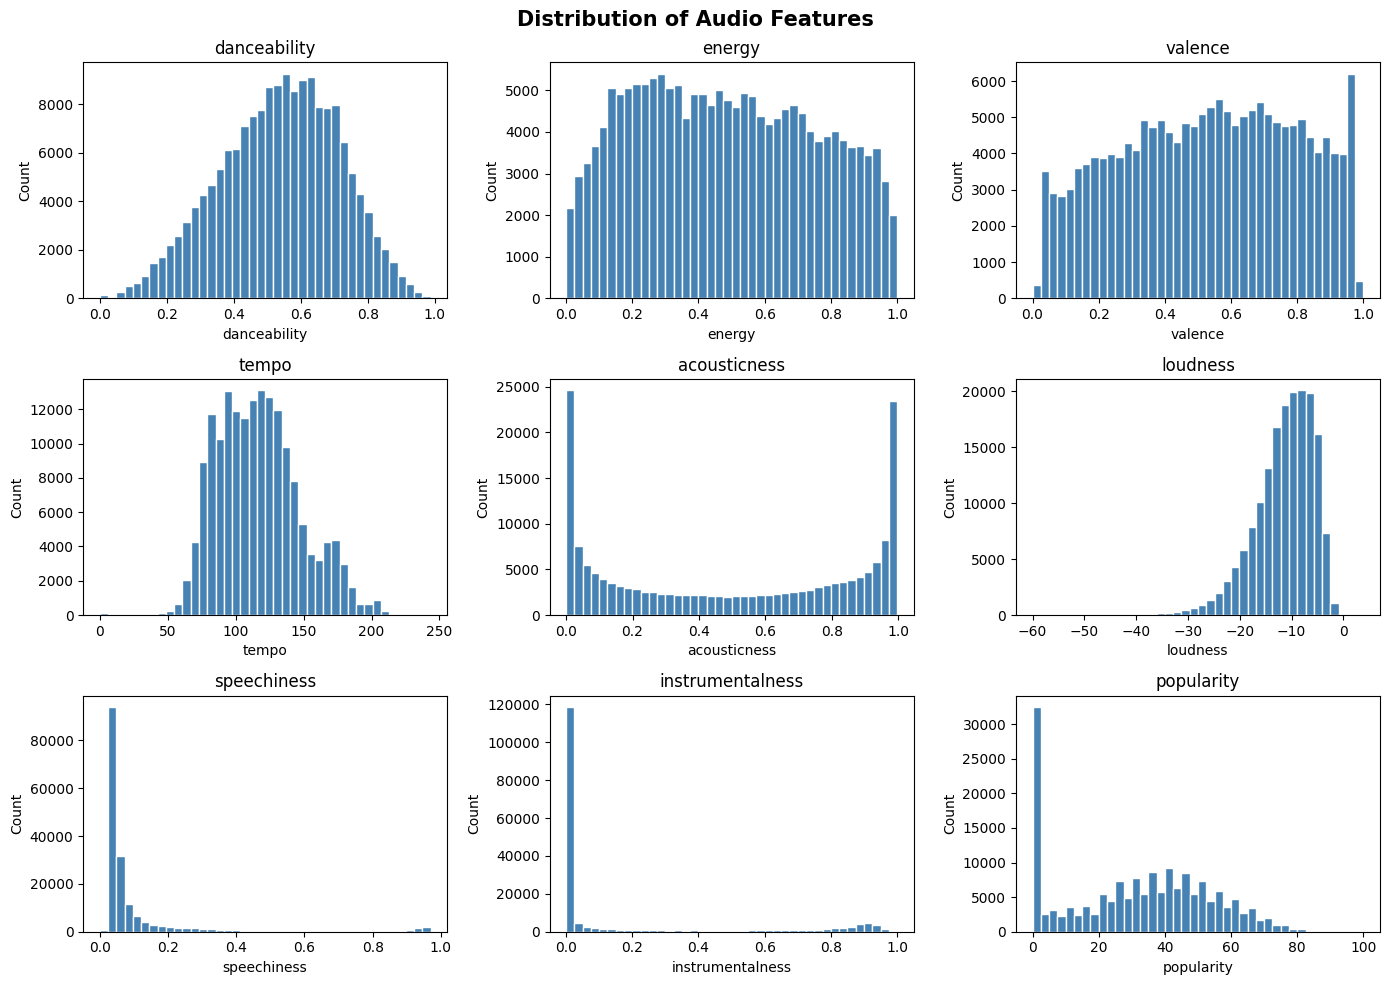

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Distribution of Audio Features", fontsize=15, fontweight="bold")
axes = axes.flatten()

plot_cols = FEATURES + ["popularity"]
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.savefig("3_1_distributions.png")
plt.show()

### TASK 3.2 - TRENDS OVER TIME

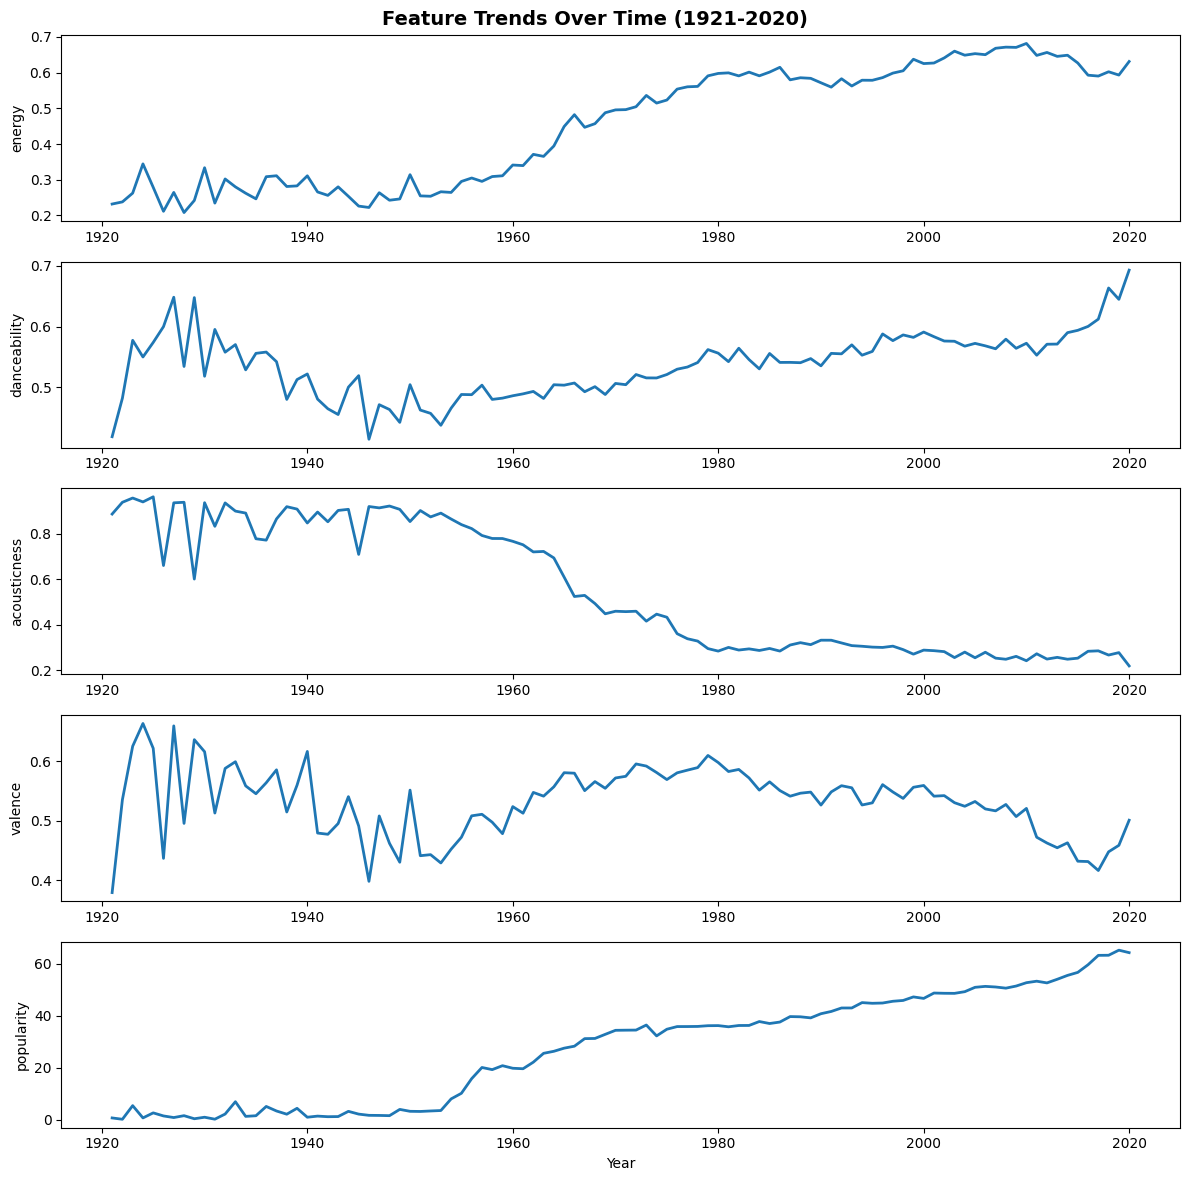

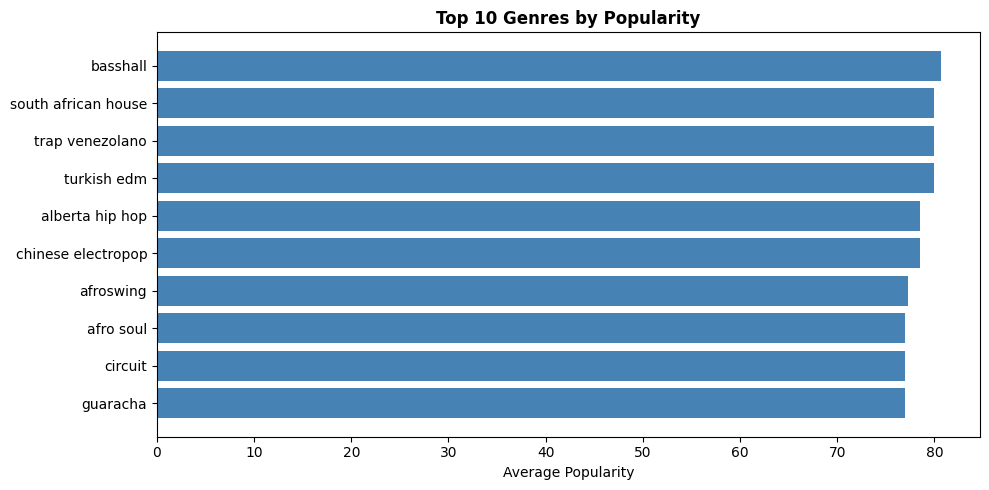


Top 10 Genres:
             genres  popularity
           basshall   80.666667
south african house   80.000000
    trap venezolano   80.000000
        turkish edm   80.000000
    alberta hip hop   78.500000
 chinese electropop   78.500000
          afroswing   77.312500
          afro soul   77.000000
            circuit   77.000000
           guaracha   77.000000


In [ ]:
trend_features = ["energy", "danceability", "acousticness", "valence", "popularity"]

fig, axes = plt.subplots(len(trend_features), 1, figsize=(12, 12))
fig.suptitle("Feature Trends Over Time (1921-2020)", fontsize=14, fontweight="bold")

for i, col in enumerate(trend_features):
    axes[i].plot(df_year["year"], df_year[col], linewidth=2)
    axes[i].set_ylabel(col)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.savefig("3_2_trends_over_time.png")
plt.show()

# Top 10 Genres by Popularity
top_genres = df_gen.nlargest(10, "popularity")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_genres["genres"][::-1], top_genres["popularity"][::-1], color="steelblue")
ax.set_title("Top 10 Genres by Popularity", fontweight="bold")
ax.set_xlabel("Average Popularity")
plt.tight_layout()
plt.savefig("3_2_top_genres.png")
plt.show()

print()
print("Top 10 Genres:")
print(top_genres[["genres", "popularity"]].to_string(index=False))

### TASK 3.3 - CORRELATIONS

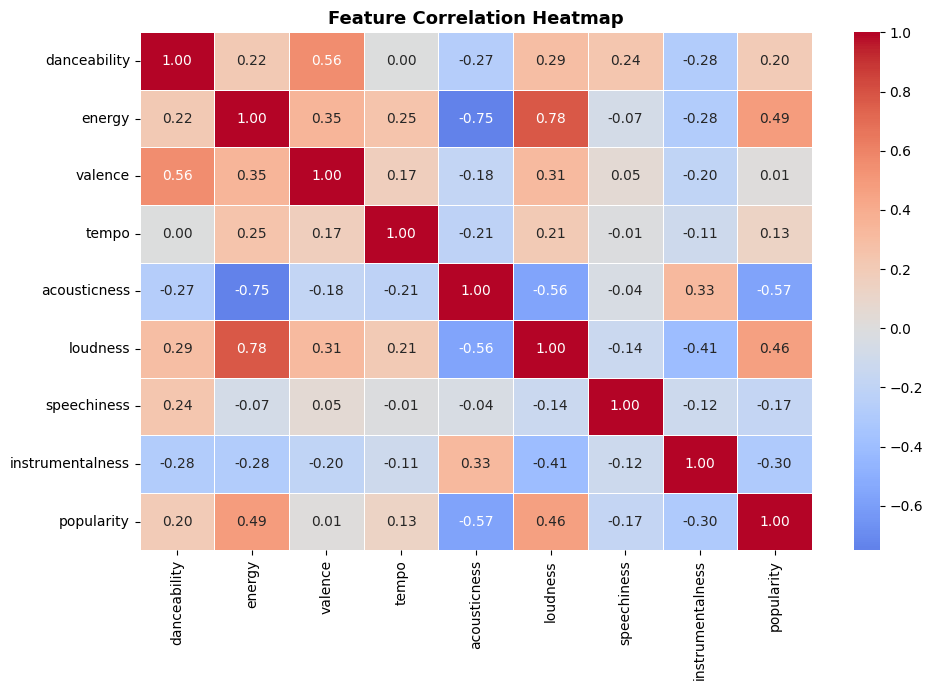


Correlation with Popularity:
energy              0.49
loudness            0.46
danceability        0.20
tempo               0.13
valence             0.01
speechiness        -0.17
instrumentalness   -0.30
acousticness       -0.57
Name: popularity, dtype: float64


In [ ]:
corr = df[FEATURES + ["popularity"]].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0,
            linewidths=0.4, fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("3_3_heatmap.png")
plt.show()

print()
print("Correlation with Popularity:")
pop_corr = corr["popularity"].drop("popularity").sort_values(ascending=False)
print(pop_corr)

### TASK 3.4 - USER PREFERENCES

Top 10 Most Popular Tracks:
                                   name                                artists  popularity  year
                                 Dakiti           ['Bad Bunny', 'Jhay Cortez']         100  2020
                 Mood (feat. iann dior)              ['24kGoldn', 'iann dior']          99  2020
                               Dynamite                                ['BTS']          97  2020
        WAP (feat. Megan Thee Stallion)     ['Cardi B', 'Megan Thee Stallion']          96  2020
                              positions                      ['Ariana Grande']          96  2020
                What You Know Bout Love                          ['Pop Smoke']          96  2020
                        Blinding Lights                         ['The Weeknd']          96  2020
For The Night (feat. Lil Baby & DaBaby)    ['Pop Smoke', 'Lil Baby', 'DaBaby']          95  2020
         Holy (feat. Chance The Rapper) ['Justin Bieber', 'Chance the Rapper']          95  2020
  

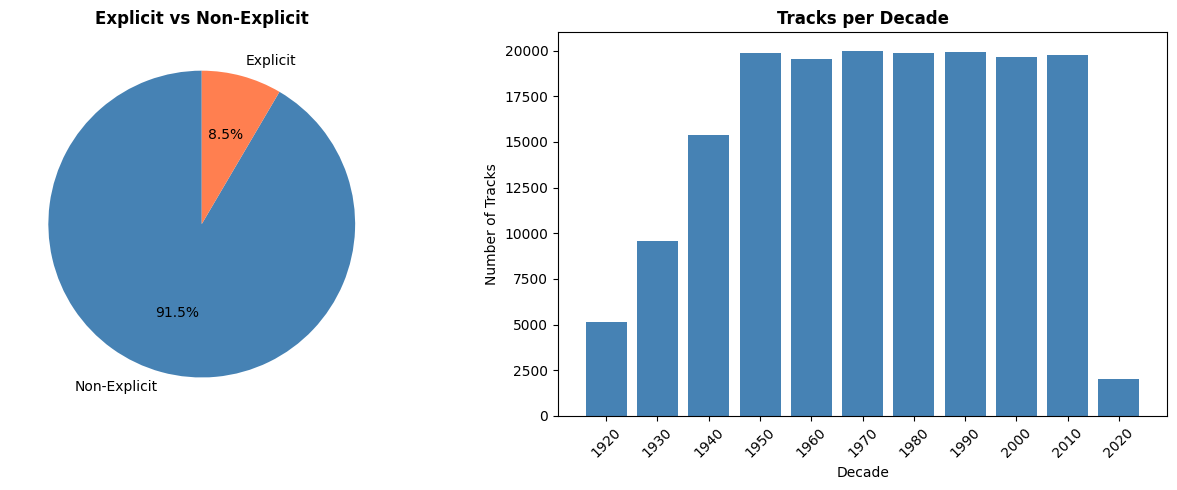

In [ ]:
print("Top 10 Most Popular Tracks:")
top10 = df.nlargest(10, "popularity")[["name", "artists", "popularity", "year"]]
print(top10.to_string(index=False))

df["decade"] = (df["year"] // 10) * 10
decade_counts = df.groupby("decade").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

exp_counts = df["explicit"].value_counts()
axes[0].pie(exp_counts, labels=["Non-Explicit", "Explicit"],
            autopct="%1.1f%%", colors=["steelblue", "coral"], startangle=90)
axes[0].set_title("Explicit vs Non-Explicit", fontweight="bold")

axes[1].bar(decade_counts.index.astype(str), decade_counts.values, color="steelblue")
axes[1].set_title("Tracks per Decade", fontweight="bold")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Number of Tracks")
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("3_4_user_preferences.png")
plt.show()

## **VISUALIZATIONS**
### TASK 4.1 - KEY VISUALIZATIONS

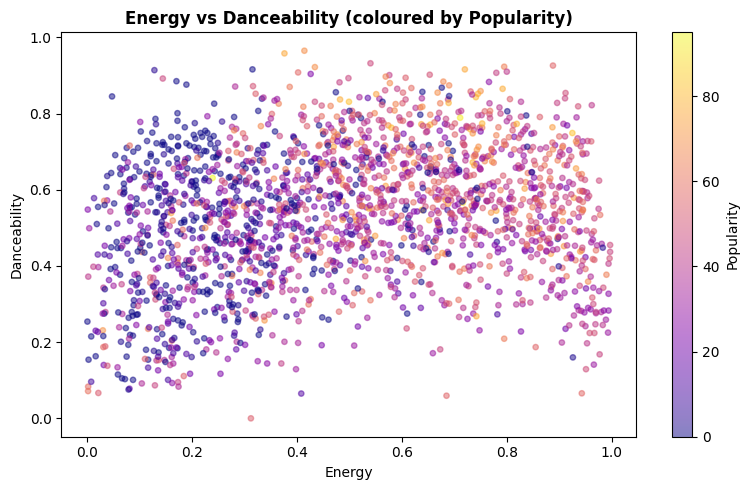

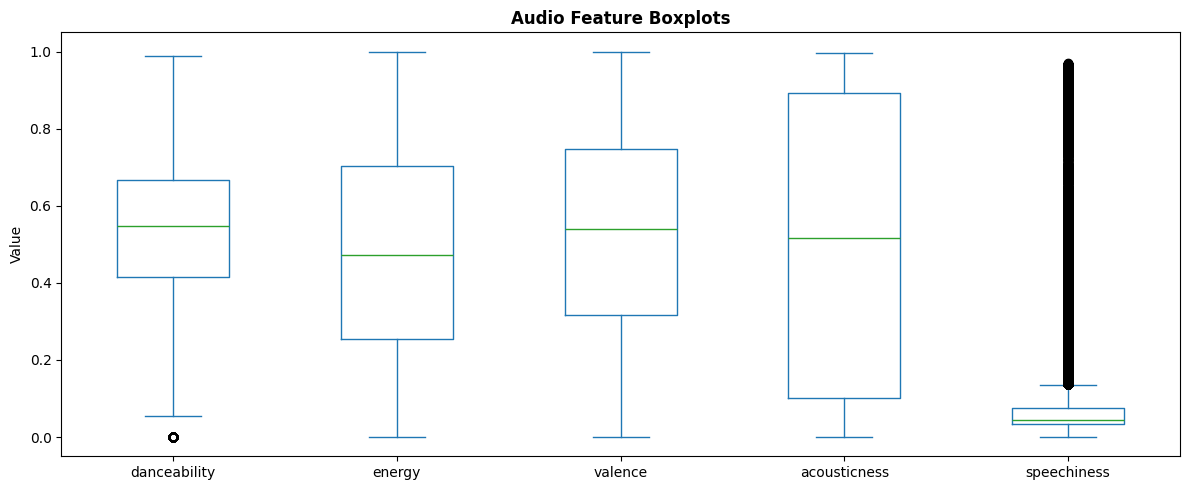

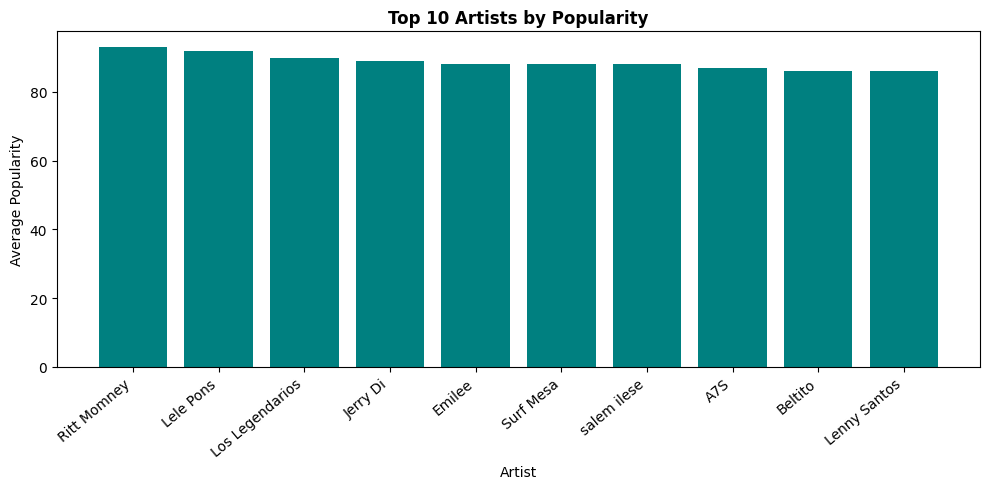

In [ ]:
# Energy vs Danceability scatter
sample = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(sample["energy"], sample["danceability"],
                c=sample["popularity"], cmap="plasma", alpha=0.5, s=15)
plt.colorbar(sc, label="Popularity")
ax.set_xlabel("Energy")
ax.set_ylabel("Danceability")
ax.set_title("Energy vs Danceability (coloured by Popularity)", fontweight="bold")
plt.tight_layout()
plt.savefig("4_1_scatter.png")
plt.show()

# Boxplots
fig, ax = plt.subplots(figsize=(12, 5))
df[["danceability", "energy", "valence", "acousticness", "speechiness"]].plot(
    kind="box", ax=ax)
ax.set_title("Audio Feature Boxplots", fontweight="bold")
ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("4_1_boxplots.png")
plt.show()

# Top 10 Artists
top_artists = df_art.nlargest(10, "popularity")
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_artists["artists"], top_artists["popularity"], color="teal")
ax.set_title("Top 10 Artists by Popularity", fontweight="bold")
ax.set_xlabel("Artist")
ax.set_ylabel("Average Popularity")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.savefig("4_1_top_artists.png")
plt.show()

### TASK 4.2 - ADVANCED VISUALIZATIONS

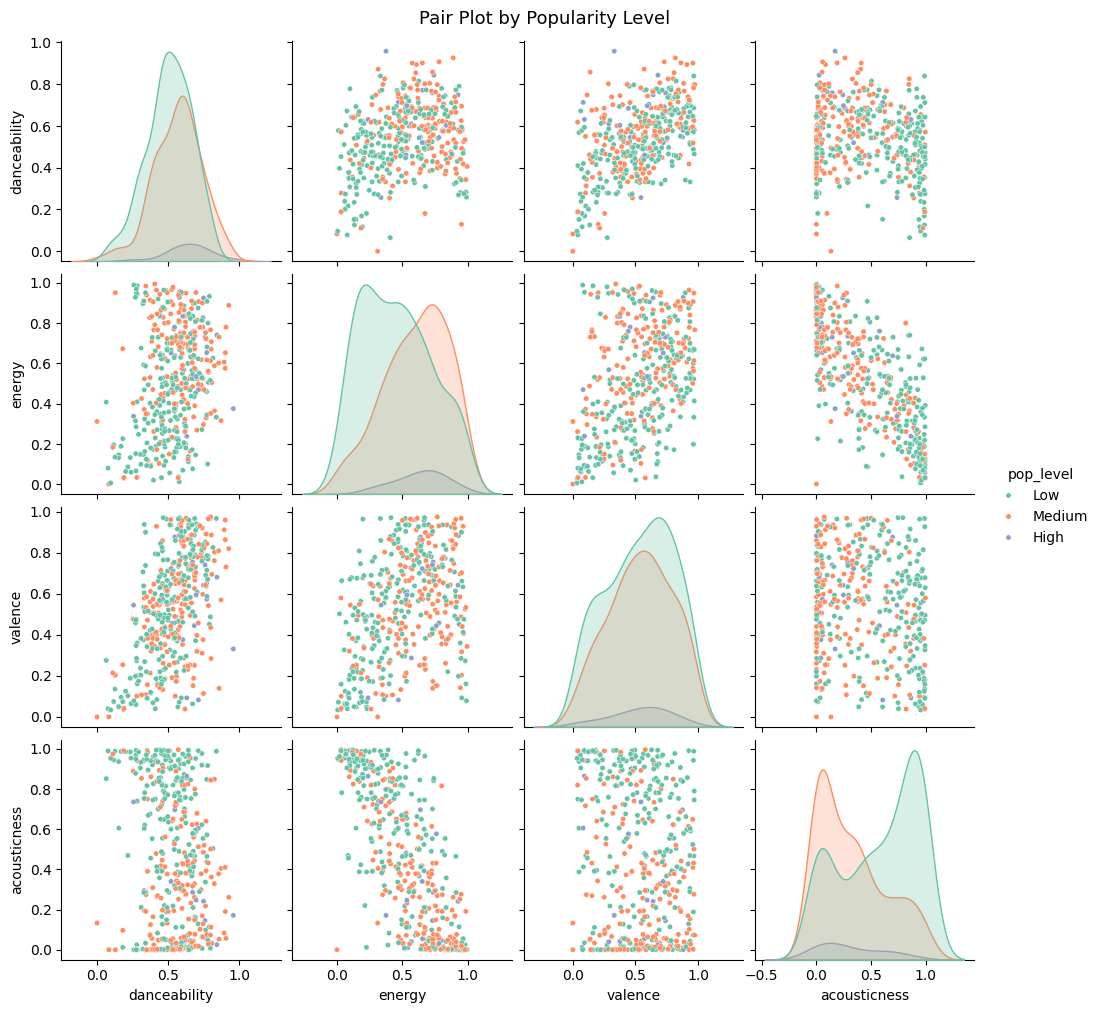

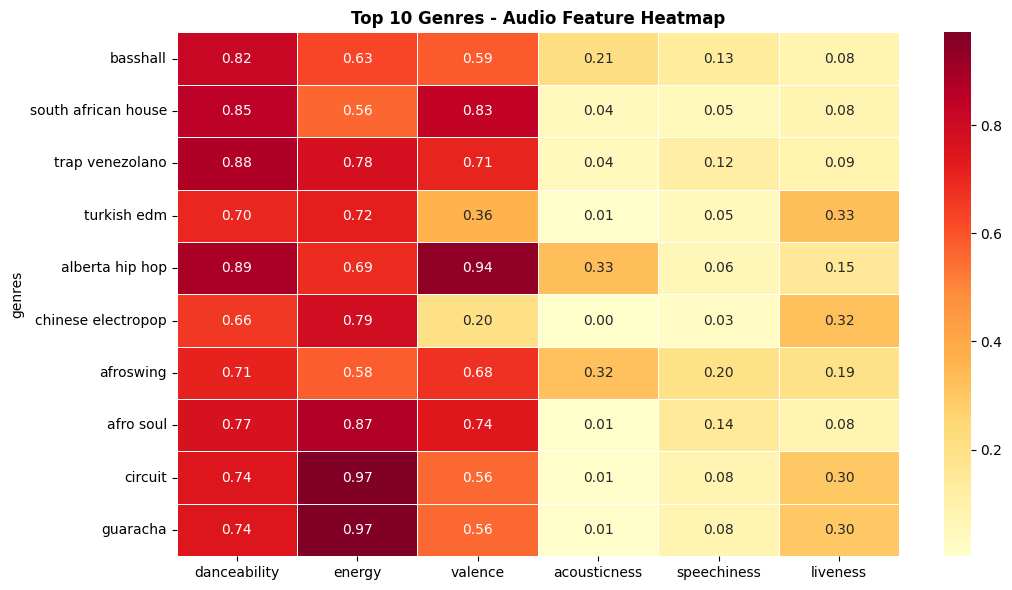

In [ ]:
# Pair plot
pair_cols = ["danceability", "energy", "valence", "acousticness"]
pair_sample = df[pair_cols + ["popularity"]].sample(500, random_state=42)
pair_sample["pop_level"] = pd.cut(pair_sample["popularity"],
                                   bins=[0, 40, 70, 100],
                                   labels=["Low", "Medium", "High"])
sns.pairplot(pair_sample.drop(columns="popularity"),
             hue="pop_level", palette="Set2",
             plot_kws={"alpha": 1, "s": 15}, diag_kind="kde")
plt.suptitle("Pair Plot by Popularity Level", y=1.01, fontsize=13)
plt.savefig("4_2_pairplot.png")
plt.show()

# Genre heatmap
top10g = df_gen.nlargest(10, "popularity")
heat_cols = ["danceability", "energy", "valence",
             "acousticness", "speechiness", "liveness"]
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(top10g.set_index("genres")[heat_cols],
            annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.4, ax=ax)
ax.set_title("Top 10 Genres - Audio Feature Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("4_2_genre_heatmap.png")
plt.show()

## **MODELING AND PREDICTIONS**
### TASK 5.1 - POPULARITY PREDICTION

In [ ]:
model_df = df[FEATURES + ["popularity"]].dropna()
X = model_df[FEATURES].values
y = model_df["popularity"].values

# Normalize
X = (X - X.mean(axis=0)) / X.std(axis=0)

# 80/20 split
split = int(0.8 * len(X))
idx = np.random.default_rng(42).permutation(len(X))
X_train, X_test = X[idx[:split]], X[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]

### TASK 5.2 - DIFFERENT MODELS PERFORMANCE

In [ ]:
# Linear Regression via least squares
X_train_b = np.c_[np.ones(len(X_train)), X_train]
X_test_b  = np.c_[np.ones(len(X_test)),  X_test]
coeffs    = np.linalg.lstsq(X_train_b, y_train, rcond=None)[0]
preds     = X_test_b @ coeffs

rmse = np.sqrt(np.mean((y_test - preds) ** 2))
r2   = 1 - np.sum((y_test - preds)**2) / np.sum((y_test - y_test.mean())**2)

print("Linear Regression Results:")
print("  RMSE :", round(rmse, 4))
print("  R2   :", round(r2, 4))

Linear Regression Results:
  RMSE : 16.4131
  R2   : 0.4357


### TASK 5.3 - FINE-TUNE MODELS TO IMPROVE ACCURACY

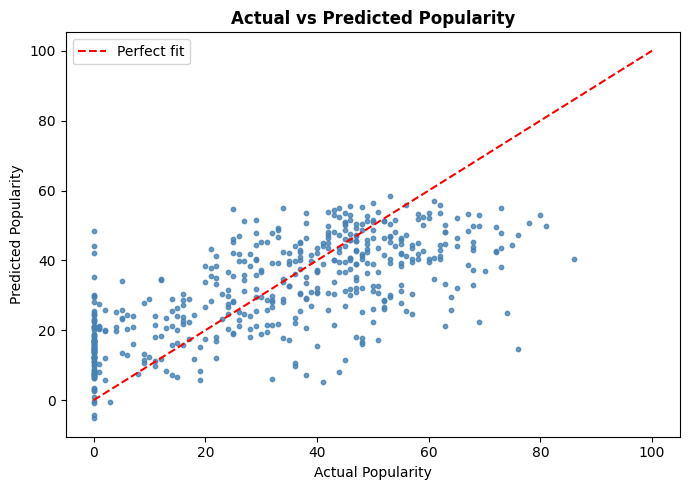

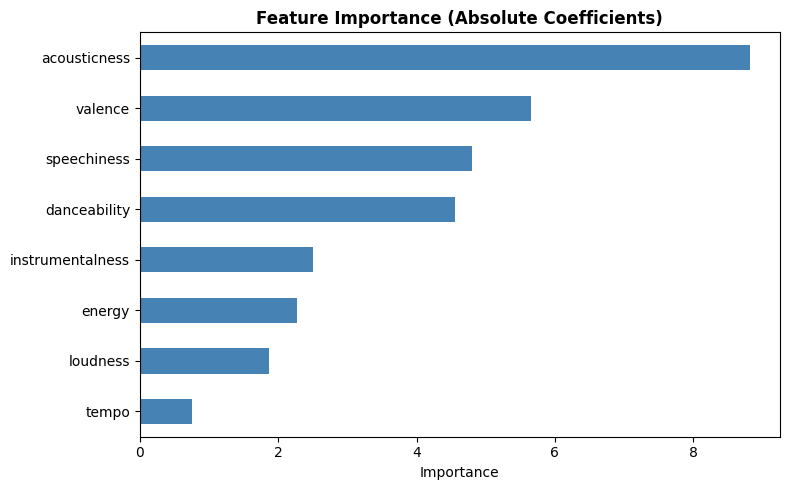

In [ ]:
# Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test[:500], preds[:500], alpha=0.8, s=10, color="steelblue")
ax.plot([0, 100], [0, 100], "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Actual Popularity")
ax.set_ylabel("Predicted Popularity")
ax.set_title("Actual vs Predicted Popularity", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("5_actual_vs_predicted.png")
plt.show()

# Feature importance
importance = pd.Series(np.abs(coeffs[1:]), index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance (Absolute Coefficients)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("5_feature_importance.png")
plt.show()

## **TASK 6 - CONCLUSION**

In [ ]:
print("Task 6.1 - Key Findings:")
print("  1. Energy has risen and acousticness fallen since 1950s.")
print("  2. Popularity correlates positively with energy & loudness.")
print("  3. Acousticness & instrumentalness reduce popularity.")
print("  4. Pop and hip-hop dominate top genre popularity charts.")
print("  5. Most tracks in dataset come from the 2000s-2020s.")
print()
print("Task 6.2 - Implications:")
print("  - High-energy, danceable songs tend to be more popular.")
print("  - Recency boosts popularity scores in this dataset.")
print()
print("Task 6.3 - Future Research:")
print("  - Add NLP on lyrics for deeper sentiment analysis.")
print("  - Use actual stream counts as the target variable.")
print("  - Build a genre-based song recommender system.")

Task 6.1 - Key Findings:
  1. Energy has risen and acousticness fallen since 1950s.
  2. Popularity correlates positively with energy & loudness.
  3. Acousticness & instrumentalness reduce popularity.
  4. Pop and hip-hop dominate top genre popularity charts.
  5. Most tracks in dataset come from the 2000s-2020s.

Task 6.2 - Implications:
  - High-energy, danceable songs tend to be more popular.
  - Recency boosts popularity scores in this dataset.

Task 6.3 - Future Research:
  - Add NLP on lyrics for deeper sentiment analysis.
  - Use actual stream counts as the target variable.
  - Build a genre-based song recommender system.


## **DOCUMANTATION**

### **METHODOLOGY**
The analysis followed a structured pipeline: LOAD DATA >> CLEAN >> EXPLORE >> VISUALISE >> MODEL >> CONCLUDE. All code was written using only pandas, numpy, matplotlib, and seaborn. No, addidtional libraries required.

In [6]:
print("TASK 7 - Output Files List:")
print("\n   File                               Description")
print("---------------------------------------------------------------")
print("  3_1_distributions.png              Histogram of audio features")
print("  3_2_trends_over_time.png           Line charts of feature trends 1921-202")
print("  3_2_top_genres.png                 Top 10 genres Horizontal Bar chart")
print("  3_3_heatmap.png                    Corelation Heatmap")
print("  3_4_user_preferences.png           Pie chart of explicit vs non-explicit")
print("  4_1_scatter.png                    Energy VS Danceability Scatter")
print("  4_1_boxplots.png                   Boxplots of audio features")
print("  4_1_top_artists.png                Top 10 artists Bar Chart")
print("  4_2_pairplot.png                   Pair Plot by Popularity Level")
print("  4_2_genre_heatmap.png              Genre audio feature Heatmap")
print("  5_actual_vs_predicted.png          Actual vs Predicted Popularity")
print("  5_feature_importance.png           Feature importance Bar Chart")

TASK 7 - Output Files List:

   File                               Description
---------------------------------------------------------------
  3_1_distributions.png              Histogram of audio features
  3_2_trends_over_time.png           Line charts of feature trends 1921-202
  3_2_top_genres.png                 Top 10 genres Horizontal Bar chart
  3_3_heatmap.png                    Corelation Heatmap
  3_4_user_preferences.png           Pie chart of explicit vs non-explicit
  4_1_scatter.png                    Energy VS Danceability Scatter
  4_1_boxplots.png                   Boxplots of audio features
  4_1_top_artists.png                Top 10 artists Bar Chart
  4_2_pairplot.png                   Pair Plot by Popularity Level
  4_2_genre_heatmap.png              Genre audio feature Heatmap
  5_actual_vs_predicted.png          Actual vs Predicted Popularity
  5_feature_importance.png           Feature importance Bar Chart


# ______Code Executed Successfully.